# Machine Learning Engineer Nanodegree
## Model Evaluation & Validation
## Project: Predicting Boston Housing Prices

#### Student: Whitney King
#### Cohort:  July 2018

Welcome to the first project of the Machine Learning Engineer Nanodegree! In this notebook, some template code has already been provided for you, and you will need to implement additional functionality to successfully complete this project. You will not need to modify the included code beyond what is requested. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a 'TODO' statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started
In this project, you will evaluate the performance and predictive power of a model that has been trained and tested on data collected from homes in suburbs of Boston, Massachusetts. A model trained on this data that is seen as a *good fit* could then be used to make certain predictions about a home — in particular, its monetary value. This model would prove to be invaluable for someone like a real estate agent who could make use of such information on a daily basis.

The dataset for this project originates from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Housing). The Boston housing data was collected in 1978 and each of the 506 entries represent aggregated data about 14 features for homes from various suburbs in Boston, Massachusetts. For the purposes of this project, the following preprocessing steps have been made to the dataset:
- 16 data points have an `'MEDV'` value of 50.0. These data points likely contain **missing or censored values** and have been removed.
- 1 data point has an `'RM'` value of 8.78. This data point can be considered an **outlier** and has been removed.
- The features `'RM'`, `'LSTAT'`, `'PTRATIO'`, and `'MEDV'` are essential. The remaining **non-relevant features** have been excluded.
- The feature `'MEDV'` has been **multiplicatively scaled** to account for 35 years of market inflation.

Run the code cell below to load the Boston housing dataset, along with a few of the necessary Python libraries required for this project. You will know the dataset loaded successfully if the size of the dataset is reported.

In [1]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from sklearn.model_selection import ShuffleSplit

# Import supplementary visualization|s code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('ggplot')

# Load the Boston housing dataset
data = pd.read_csv('housing.csv')
prices = data['MEDV']
features = data.drop('MEDV', axis = 1)
    
# Success
print("Boston housing dataset has {} data points with {} variables each.".format(*data.shape))

Boston housing dataset has 489 data points with 4 variables each.


## Data Exploration
In this first section of this project, you will make a cursory investigation about the Boston housing data and provide your observations. Familiarizing yourself with the data through an explorative process is a fundamental practice to help you better understand and justify your results.

Since the main goal of this project is to construct a working model which has the capability of predicting the value of houses, we will need to separate the dataset into **features** and the **target variable**. The **features**, `'RM'`, `'LSTAT'`, and `'PTRATIO'`, give us quantitative information about each data point. The **target variable**, `'MEDV'`, will be the variable we seek to predict. These are stored in `features` and `prices`, respectively.

### Implementation: Calculate Statistics
For your very first coding implementation, you will calculate descriptive statistics about the Boston housing prices. Since `numpy` has already been imported for you, use this library to perform the necessary calculations. These statistics will be extremely important later on to analyze various prediction results from the constructed model.

In the code cell below, you will need to implement the following:
- Calculate the minimum, maximum, mean, median, and standard deviation of `'MEDV'`, which is stored in `prices`.
  - Store each calculation in their respective variable.

In [2]:
# TODO: Minimum price of the data
minimum_price = np.min(prices)

# TODO: Maximum price of the data
maximum_price = np.max(prices)

# TODO: Mean price of the data
mean_price = np.mean(prices)

# TODO: Median price of the data
median_price = np.median(prices)

# TODO: Standard deviation of prices of the data
std_price = np.std(prices)

# Show the calculated statistics
print("Statistics for Boston housing dataset:\n")
print("Minimum price: ${:,.2f}".format(minimum_price)) 
print("Maximum price: ${:,.2f}".format(maximum_price))
print("Mean price: ${:,.2f}".format(mean_price))
print("Median price ${:,.2f}".format(median_price))
print("Standard deviation of prices: ${:,.2f}".format(std_price))

Statistics for Boston housing dataset:

Minimum price: $105,000.00
Maximum price: $1,024,800.00
Mean price: $454,342.94
Median price $438,900.00
Standard deviation of prices: $165,171.13


### Question 1 - Feature Observation
As a reminder, we are using three features from the Boston housing dataset: `'RM'`, `'LSTAT'`, and `'PTRATIO'`. For each data point (neighborhood):
- `'RM'` is the average number of rooms among homes in the neighborhood.
- `'LSTAT'` is the percentage of homeowners in the neighborhood considered "lower class" (working poor).
- `'PTRATIO'` is the ratio of students to teachers in primary and secondary schools in the neighborhood.


** Using your intuition, for each of the three features above, do you think that an increase in the value of that feature would lead to an **increase** in the value of `'MEDV'` or a **decrease** in the value of `'MEDV'`? Justify your answer for each.**

**Hint:** This problem can phrased using examples like below.  
* Would you expect a home that has an `'RM'` value(number of rooms) of 6 be worth more or less than a home that has an `'RM'` value of 7?
* Would you expect a neighborhood that has an `'LSTAT'` value(percent of lower class workers) of 15 have home prices be worth more or less than a neighborhood that has an `'LSTAT'` value of 20?
* Would you expect a neighborhood that has an `'PTRATIO'` value(ratio of students to teachers) of 10 have home prices be worth more or less than a neighborhood that has an `'PTRATIO'` value of 15?

**Answer: **

To evaluate each of the three features that could potentially impact the value of ```MEDV```, they should first be treated independent of each other and considered separately:

-  **```RM```** (number of rooms)
>  When considering factors that impact the price of a home, **square footage** is one of the primary factors used to break down the cost. It stands to reason that the more rooms a home has, the larger it is likely to be; thus the more expensive it is likely to be. There are cases where some homes have a larger number of very small rooms, but in general it's likely fine to consider more rooms to be indicative of more square footage. 
<br>
<br>
**With this reasoning, I would generally expect a home with ```RM(6)``` to be worth *less than* a home with ```RM(7)```.**
<br>
$RM(6) < RM(7)$
  
-  **```LSTAT```** (% of lower class workers in neighborhood)
> One of the most pervasive issues seen across urban areas of the United States is neighborhood-based class-divisions. This can be visualized by colorized mapping of virtually any city by per capita income, and tend to show clear divides and lines as to where upper class, middle class, and lower class citizens can afford to live. 
<br>
<br>
  *Examples:  [New York Neighborhood Class-Division](https://www.citylab.com/equity/2013/01/class-divided-cities-new-york-edition/3819/) | [Chicago Neighborhood Class-Division](https://www.citylab.com/equity/2013/02/class-divided-cities-chicago-edition/4306/)*
<br>
<br>
Since the area in which someone lives is directly impacted by their ability to afford living there, I would expect that the higher the percentage of lower class workers in a neighborhood, the lower the average home value is (ie. an inverse/negative correlation). **Thus, I would expect that a home with ```LSTAT(15)``` would generally be worth more than a home with ```LSTAT(20)```.**
<br>
$LSTAT(15) > LSTAT(20)$

-  **```PTRATIO```** ($student:teacher$ ratio in neighborhood)
> Areas in which the $student:teacher$ ratio is lower should be reflective of a well-supported educational system in that area. Most educational systems are supported in part by property taxes, which are reflective of a percentage of the value of a home. The additional tax income generated by property taxes on higher values homes would allow schools wiggle room to offer programs and services that benefit the students, including lower student:teacher ratios. Generally, less students per teacher in an urban area would be indicative of a school that could support funding smaller classroom sizes, thus offering a higher level of attention teachers devote individually to each student. 
<br>
<br>
**With this in mind, I would expect neighborhoods with lower ```PTRATIO``` to have higher home values**.
<br>
$PTRATIO(10) > PTRATIO(15)$


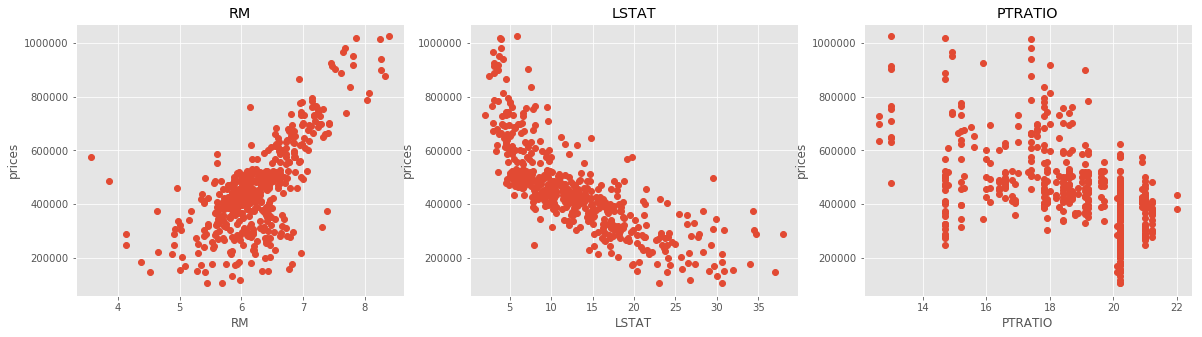

In [27]:
# Code snippet from #code Slack channel to visually support conclusions drawn
plt.figure(figsize=(20, 5))
for i, col in enumerate(features.columns):
    plt.subplot(1, 3, i+1)
    plt.plot(data[col], prices, 'o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('prices')

----

## Developing a Model
In this second section of the project, you will develop the tools and techniques necessary for a model to make a prediction. Being able to make accurate evaluations of each model's performance through the use of these tools and techniques helps to greatly reinforce the confidence in your predictions.

### Implementation: Define a Performance Metric
It is difficult to measure the quality of a given model without quantifying its performance over training and testing. This is typically done using some type of performance metric, whether it is through calculating some type of error, the goodness of fit, or some other useful measurement. For this project, you will be calculating the [*coefficient of determination*](http://stattrek.com/statistics/dictionary.aspx?definition=coefficient_of_determination), R<sup>2</sup>, to quantify your model's performance. The coefficient of determination for a model is a useful statistic in regression analysis, as it often describes how "good" that model is at making predictions. 

The values for R<sup>2</sup> range from 0 to 1, which captures the percentage of squared correlation between the predicted and actual values of the **target variable**. A model with an R<sup>2</sup> of 0 is no better than a model that always predicts the *mean* of the target variable, whereas a model with an R<sup>2</sup> of 1 perfectly predicts the target variable. Any value between 0 and 1 indicates what percentage of the target variable, using this model, can be explained by the **features**. _A model can be given a negative R<sup>2</sup> as well, which indicates that the model is **arbitrarily worse** than one that always predicts the mean of the target variable._

For the `performance_metric` function in the code cell below, you will need to implement the following:
- Use `r2_score` from `sklearn.metrics` to perform a performance calculation between `y_true` and `y_predict`.
- Assign the performance score to the `score` variable.

In [4]:
data.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [5]:
# TODO: Import 'r2_score'
from sklearn.metrics import r2_score

def performance_metric(y_true, y_predict):
    """ Calculates and returns the performance score between 
        true and predicted values based on the metric chosen. """
    
    # TODO: Calculate the performance score between 'y_true' and 'y_predict'
    score = r2_score(y_true, y_predict)
    
    # Return the score
    return score

### Question 2 - Goodness of Fit
Assume that a dataset contains five data points and a model made the following predictions for the target variable:

| True Value | Prediction |
| :-------------: | :--------: |
| 3.0 | 2.5 |
| -0.5 | 0.0 |
| 2.0 | 2.1 |
| 7.0 | 7.8 |
| 4.2 | 5.3 |

Run the code cell below to use the `performance_metric` function and calculate this model's coefficient of determination.

In [6]:
# Calculate the performance of this model
score = performance_metric([3, -0.5, 2, 7, 4.2], [2.5, 0.0, 2.1, 7.8, 5.3])
print("Model has a coefficient of determination, R^2, of {:.3f}.".format(score))

Model has a coefficient of determination, R^2, of 0.923.


* Would you consider this model to have successfully captured the variation of the target variable? 
* Why or why not?

** Hint: **  The R2 score is the proportion of the variance in the dependent variable that is predictable from the independent variable. In other words:
* R2 score of 0 means that the dependent variable cannot be predicted from the independent variable.
* R2 score of 1 means the dependent variable can be predicted from the independent variable.
* R2 score between 0 and 1 indicates the extent to which the dependent variable is predictable. An 
* R2 score of 0.40 means that 40 percent of the variance in Y is predictable from X.

**Answer:**

With an $R^2$ score of $0.923$, **I would consider the model to have mostly successfully captured the variation of the target variable.** Overall, $0.923\ (92.3\%)$ is extremely close to $1\ (100\%)$, indicating the dependent variable can be predicted via the independent variable. However, it's important to consider that this dataset is fairly small, so the confidence is which we can trust that prediction is weak, since it's likely to be underfit.

### Implementation: Shuffle and Split Data
Your next implementation requires that you take the Boston housing dataset and split the data into training and testing subsets. Typically, the data is also shuffled into a random order when creating the training and testing subsets to remove any bias in the ordering of the dataset.

For the code cell below, you will need to implement the following:
- Use `train_test_split` from `sklearn.cross_validation` to shuffle and split the `features` and `prices` data into training and testing sets.
  - Split the data into 80% training and 20% testing.
  - Set the `random_state` for `train_test_split` to a value of your choice. This ensures results are consistent.
- Assign the train and testing splits to `X_train`, `X_test`, `y_train`, and `y_test`.

In [7]:
# TODO: Import 'train_test_split'
from sklearn.model_selection import train_test_split

X = features
y = prices

# TODO: Shuffle and split the data into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

# Success
print("Training and testing split was successful.")
print('Train Samples: ', len(X_train))
print('Test Samples: ', len(X_test))

Training and testing split was successful.
Train Samples:  391
Test Samples:  98


### Question 3 - Training and Testing

* What is the benefit to splitting a dataset into some ratio of training and testing subsets for a learning algorithm?

**Hint:** Think about how overfitting or underfitting is contingent upon how splits on data is done.

**Answer: **

It's important to reserve a subset of known samples when building a model so that we can use one of the sets for training our model, and then the other for testing it's performance against any theoretical 'yet unknown' items it might encounter in the future. This is where splitting the dataset into train and test sets arises, as it allows us to reserve a subset of our sample data to ensure the predictions the model makes after being learning on the training data are in line with the expectations of the model performance going forward (ie, the model is not over- or underfit). There are a few considerations to keep in mind when splitting data:

-  Not reserving known data to test model performance leads to overfitting, as models perform better when performance is measured against the data it was trained on.
-  Data should be split in a randomized way to ensure that whatever data is sequestered for measuring model performance isn't reflective of only a specific grouping of the sample data.
-  Test sample size should be a large enough chunk of the overall sample size to ensure any performance measurements can be confidently relied upon, as well as helps prevent underfitting.

----

## Analyzing Model Performance
In this third section of the project, you'll take a look at several models' learning and testing performances on various subsets of training data. Additionally, you'll investigate one particular algorithm with an increasing `'max_depth'` parameter on the full training set to observe how model complexity affects performance. Graphing your model's performance based on varying criteria can be beneficial in the analysis process, such as visualizing behavior that may not have been apparent from the results alone.

### Learning Curves
The following code cell produces four graphs for a decision tree model with different maximum depths. Each graph visualizes the learning curves of the model for both training and testing as the size of the training set is increased. Note that the shaded region of a learning curve denotes the uncertainty of that curve (measured as the standard deviation). The model is scored on both the training and testing sets using R<sup>2</sup>, the coefficient of determination.  

Run the code cell below and use these graphs to answer the following question.

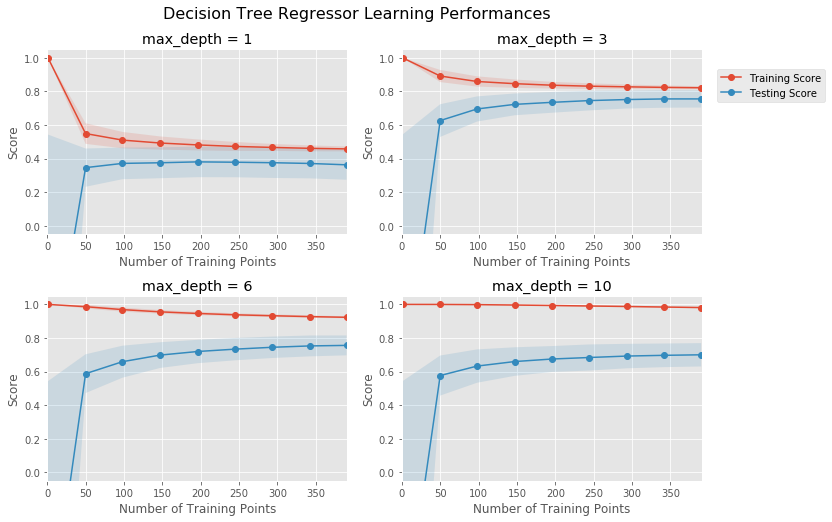

In [8]:
# Produce learning curves for varying training set sizes and maximum depths
vs.ModelLearning(features, prices)

### Question 4 - Learning the Data
* Choose one of the graphs above and state the maximum depth for the model. 
* What happens to the score of the training curve as more training points are added? What about the testing curve? 
* Would having more training points benefit the model? 

**Hint:** Are the learning curves converging to particular scores? Generally speaking, the more data you have, the better. But if your training and testing curves are converging with a score above your benchmark threshold, would this be necessary?
Think about the pros and cons of adding more training points based on if the training and testing curves are converging.

**Answer: **

At a glance, I believe the **top right graph with a ```max_depth = 3```** to be the most viable model. What is most interesting about this graph as compared to the others is:

-  The ```training``` and ```testing``` sets begin to converge at a much higher score (around **```.8```**) than any of the other models given the sample sizes we have to work with.
- The standard deviation of the performance in both ```training``` and ```testing``` sets is extremely tight, so there's reatively little variance.
- As the number of ```training``` points increases, the score of the training model gradually decreases, however the score of the ```testing``` model gradually increases, moving the scores extremely close together at around ```300``` datapoints.
  - The closer the scores ```training``` and ```testing``` sets, the more reliable we can consider the predictions of the model.
  - Beyond 300 data points, it doesn't appear the performance of the two set moves much more closely together, and in fact looks like the performance for the ```testing``` set may have leveled off.
  
**With these considerations, a ```training``` size somewhere around ```300```, is going to result in an optimal performance given the size of the entire dataset.**

### Complexity Curves
The following code cell produces a graph for a decision tree model that has been trained and validated on the training data using different maximum depths. The graph produces two complexity curves — one for training and one for validation. Similar to the **learning curves**, the shaded regions of both the complexity curves denote the uncertainty in those curves, and the model is scored on both the training and validation sets using the `performance_metric` function.  

** Run the code cell below and use this graph to answer the following two questions Q5 and Q6. **

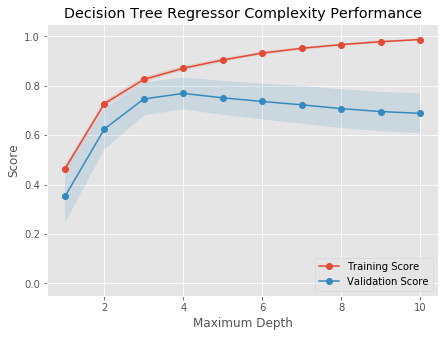

In [9]:
vs.ModelComplexity(X_train, y_train)

### Question 5 - Bias-Variance Tradeoff
* When the model is trained with a maximum depth of 1, does the model suffer from high bias or from high variance? 
* How about when the model is trained with a maximum depth of 10? What visual cues in the graph justify your conclusions?

**Hint:** High bias is a sign of underfitting(model is not complex enough to pick up the nuances in the data) and high variance is a sign of overfitting(model is by-hearting the data and cannot generalize well). Think about which model(depth 1 or 10) aligns with which part of the tradeoff.

**Answer: **

**When the model is trained with a maximum depth ($MD$) of $1$**, it suffers from *high bias*. **This is visually noticable on the graph**, as the lack of complexity in the model at $MD\ 1$ leaves the ```score``` very low, hovering just around $0.4$ for both the ```training``` and ```validation``` sets. This is due to the fact it's not picking up the nuances of the data's characteristics. This is an example of an underfit model.

**When the model is trained with $MD\ 10$**, it suffers from *high variance*. **This can been seen on the graph** when examining the data points at $MD\ 10$, as the ```training``` data has a ```score``` just a hair under $1$, while the ```validation``` set has a score somewhere around $0.7$. Not only that, but as the $MD$ grows larger, the two data sets are" diverging from each other more and more. The model has learned the training data instead of the characteristics of the sample population it is representing, and thus doesn't generalize well to new data when it's introduced. This is an example of overfitting.

### Question 6 - Best-Guess Optimal Model
* Which maximum depth do you think results in a model that best generalizes to unseen data? 
* What intuition lead you to this answer?

** Hint: ** Look at the graph above Question 5 and see where the validation scores lie for the various depths that have been assigned to the model. Does it get better with increased depth? At what point do we get our best validation score without overcomplicating our model? And remember, Occams Razor states "Among competing hypotheses, the one with the fewest assumptions should be selected."

**Answer: **

When examining the scores of each of the $MD$ values, it appears that the model with **$MD\ 4$ generalizes best to the unseen data**. This is due to the fact that it's where the scores for the ```validation``` set peaks before beginning to dip back down. We do see that the scores of the ```training``` and ```validation``` models begin to slightly diverge here, but not enough that it is a problem, so the validation score is at it's best. Overcomplicated models don't generalize well, and $MD\ 4$ is the simplest model with the best performance.

-----

## Evaluating Model Performance
In this final section of the project, you will construct a model and make a prediction on the client's feature set using an optimized model from `fit_model`.

### Question 7 - Grid Search
* What is the grid search technique?
* How it can be applied to optimize a learning algorithm?

** Hint: ** When explaining the Grid Search technique, be sure to touch upon why it is used,  what the 'grid' entails and what the end goal of this method is. To solidify your answer, you can also give an example of a parameter in a model that can be optimized using this approach.

**Answer: **

```GridSearch``` is a algorithm which selects the best *hyper*-parameters (parameters that exist outside the model) to fit a model. It tries multiple values for each parameter it's given, and then considers all possible combinations of those values, finally returning the combination of values with the best cross validation score for the model; thus reducing overfitting.

Some hyper-parameters that can be optimized for a model using ```GridSearch``` are things like ```max_depth```, ```min_samples_split```, and any classifier specific parameters, such as ```kernel``` for ```SVM``` classifiers.

### Question 8 - Cross-Validation

* What is the k-fold cross-validation training technique? 

* What benefit does this technique provide for grid search when optimizing a model?

**Hint:** When explaining the k-fold cross validation technique, be sure to touch upon what 'k' is, how the dataset is split into different parts for training and testing and the number of times it is run based on the 'k' value.

When thinking about how k-fold cross validation helps grid search, think about the main drawbacks of grid search which are hinged upon **using a particular subset of data for training or testing** and how k-fold cv could help alleviate that. You can refer to the [docs](http://scikit-learn.org/stable/modules/cross_validation.html#cross-validation) for your answer.

**Answer: **

To avoid the fallacy of training and testing on the same data, it becomes a necessity to have a third data split in order to ensure we're not compromising the testing data prior to the model being built. Data will still need to be reserved as unknown classification for testing while the model is being built and validated. This is where **cross validation** comes in. The training data is once again split out, and another subset of data reserved as the ```validation``` set to use for validating the model as it's built.

However, this concept introduces another layer of complication that needs to be considered and mitigated. What if the subset of data selected for training is not representative of the population at large? That is, if by some stroke of chance, most of the data points were from particularly poor areas, the model wouldn't do very well when tested with data from wealthy areas. 

One of the best solutions to this is **k-fold cross validation**. This process generates ($k$) random, equally sized combinations of the dataset, known as *folds*:
 
 -  The model is trained with $k-1$ of the folds
 -  The model is then validated with the remaining fold

The model performance is measured by the average of the values computed for each fold. Using **k-fold cross validation** with ```GridSearch``` when optimizing a model helps assist in selecting the best hyper-parameters. The optimized parameters will generalize better to the whole dataset, as well as unknown future samples.

### Implementation: Fitting a Model
Your final implementation requires that you bring everything together and train a model using the **decision tree algorithm**. To ensure that you are producing an optimized model, you will train the model using the grid search technique to optimize the `'max_depth'` parameter for the decision tree. The `'max_depth'` parameter can be thought of as how many questions the decision tree algorithm is allowed to ask about the data before making a prediction. Decision trees are part of a class of algorithms called *supervised learning algorithms*.

In addition, you will find your implementation is using `ShuffleSplit()` for an alternative form of cross-validation (see the `'cv_sets'` variable). While it is not the K-Fold cross-validation technique you describe in **Question 8**, this type of cross-validation technique is just as useful!. The `ShuffleSplit()` implementation below will create 10 (`'n_splits'`) shuffled sets, and for each shuffle, 20% (`'test_size'`) of the data will be used as the *validation set*. While you're working on your implementation, think about the contrasts and similarities it has to the K-fold cross-validation technique.

Please note that ShuffleSplit has different parameters in scikit-learn versions 0.17 and 0.18.
For the `fit_model` function in the code cell below, you will need to implement the following:
- Use [`DecisionTreeRegressor`](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html) from `sklearn.tree` to create a decision tree regressor object.
  - Assign this object to the `'regressor'` variable.
- Create a dictionary for `'max_depth'` with the values from 1 to 10, and assign this to the `'params'` variable.
- Use [`make_scorer`](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.make_scorer.html) from `sklearn.metrics` to create a scoring function object.
  - Pass the `performance_metric` function as a parameter to the object.
  - Assign this scoring function to the `'scoring_fnc'` variable.
- Use [`GridSearchCV`](http://scikit-learn.org/0.17/modules/generated/sklearn.grid_search.GridSearchCV.html) from `sklearn.grid_search` to create a grid search object.
  - Pass the variables `'regressor'`, `'params'`, `'scoring_fnc'`, and `'cv_sets'` as parameters to the object. 
  - Assign the `GridSearchCV` object to the `'grid'` variable.

In [23]:
# TODO: Import 'make_scorer', 'DecisionTreeRegressor', and 'GridSearchCV'
from sklearn.metrics import make_scorer
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, ShuffleSplit

def fit_model(X, y):
    """ Performs grid search over the 'max_depth' parameter for a 
        decision tree regressor trained on the input data [X, y]. """
    
    # Create cross-validation sets from the training data
    # sklearn version 0.18: ShuffleSplit(n_splits=10, test_size=0.1, train_size=None, random_state=None)
    # sklearn versiin 0.17: ShuffleSplit(n, n_iter=10, test_size=0.1, train_size=None, random_state=None)
    cv_sets = ShuffleSplit(n_splits = 10, test_size = 0.20, random_state = 0)

    # TODO: Create a decision tree regressor object
    regressor = DecisionTreeRegressor(random_state = 0)

    # TODO: Create a dictionary for the parameter 'max_depth' with a range from 1 to 10
    params = {'max_depth': list(range(1, 10))}

    # TODO: Transform 'performance_metric' into a scoring function using 'make_scorer' 
    scoring_fnc = make_scorer(performance_metric)

    # TODO: Create the grid search cv object --> GridSearchCV()
    # Make sure to include the right parameters in the object:
    # (estimator, param_grid, scoring, cv) which have values 'regressor', 'params', 'scoring_fnc', and 'cv_sets' respectively.
    grid = GridSearchCV(regressor, params, scoring=scoring_fnc, cv=cv_sets)

    # Fit the grid search object to the data to compute the optimal model
    grid = grid.fit(X, y)

    # Return the optimal model after fitting the data
    return grid.best_estimator_

### Making Predictions
Once a model has been trained on a given set of data, it can now be used to make predictions on new sets of input data. In the case of a *decision tree regressor*, the model has learned *what the best questions to ask about the input data are*, and can respond with a prediction for the **target variable**. You can use these predictions to gain information about data where the value of the target variable is unknown — such as data the model was not trained on.

### Question 9 - Optimal Model

* What maximum depth does the optimal model have? How does this result compare to your guess in **Question 6**?  

Run the code block below to fit the decision tree regressor to the training data and produce an optimal model.

In [24]:
# Fit the training data to the model using grid search
reg = fit_model(X_train, y_train)

# Produce the value for 'max_depth'
print("Parameter 'max_depth' is {} for the optimal model.".format(reg.get_params()['max_depth']))

Parameter 'max_depth' is 4 for the optimal model.


** Hint: ** The answer comes from the output of the code snipped above.

**Answer: **

**The optimal ```max_depth``` value is $4$**, which is in line with my answer for Question 6.

### Question 10 - Predicting Selling Prices
Imagine that you were a real estate agent in the Boston area looking to use this model to help price homes owned by your clients that they wish to sell. You have collected the following information from three of your clients:

| Feature | Client 1 | Client 2 | Client 3 |
| :---: | :---: | :---: | :---: |
| Total number of rooms in home | 5 rooms | 4 rooms | 8 rooms |
| Neighborhood poverty level (as %) | 17% | 32% | 3% |
| Student-teacher ratio of nearby schools | 15-to-1 | 22-to-1 | 12-to-1 |

* What price would you recommend each client sell his/her home at? 
* Do these prices seem reasonable given the values for the respective features? 

**Hint:** Use the statistics you calculated in the **Data Exploration** section to help justify your response.  Of the three clients, client 3 has has the biggest house, in the best public school neighborhood with the lowest poverty level; while client 2 has the smallest house, in a neighborhood with a relatively high poverty rate and not the best public schools.

Run the code block below to have your optimized model make predictions for each client's home.

In [25]:
# Produce a matrix for client data
client_data = [[5, 17, 15], # Client 1
               [4, 32, 22], # Client 2
               [8, 3, 12]]  # Client 3

# Show predictions
for i, price in enumerate(reg.predict(client_data)):
    print("Predicted selling price for Client {}'s home: ${:,.2f}".format(i+1, price))

Predicted selling price for Client 1's home: $403,025.00
Predicted selling price for Client 2's home: $237,478.72
Predicted selling price for Client 3's home: $931,636.36


**Statistics for Boston housing dataset:**
-  Minimum price: \$105,000.00
-  Maximum price: \$1,024,800.00
-  Mean price: \$454,342.94
-  Median price \$438,900.00
-  Standard deviation of prices: \$165,171.13

**Answer:**

Looking at model's predictions for each client's home value, the **output seems reasonable is fairly in line with the prices I would expect for the feature values of each client's home**. 

Validating this against the statistics calculated earlier puts Client 2's home towards the minimum end of the home value range, which is reflective of the small home size, high area poverty level, and high student-teacher ratio in area schools. On the other hand, Client 3's home is towards the maximum end of the price range, reflective of it's large size, low poverty rate, and low student-teacher ratio. Finally, Client 1 is estimated low, but still within a reasonable margin of error from the mean and median prices, reflective of it's moderate size, moderate poverty level, and moderate student-teacher ratio.

Based on this, information, **I'd recommend the following list prices for each clients home**:
-  Client 1:  \$399,999.00
-  Client 2:  \$236,999.00
-  Client 3:  \$929,999.00

These values were chosen in order to pick numbers that are close to the estimates from the model, pleasing to the eye, somewhat rounded, and will draw potential buyers in through enticing price points.

With all that said, there is a discrepency between the training data and the data used to estimate the list price these homes. For the ```RM``` column, the training data contains the *average number of rooms among all homes in an area*, whereas the predictions that were just made used the *actual number of rooms in each clients home*.  Because the scoring of these features isn't weighted, this means that if a home has a higher than average number of rooms than the area it's in, it's likely to be under valued (and conversely if it has a lower than average number of rooms). We can see from the above predictions that Client 1's home does appear to be under valued compared to the mean and median home values, but it wasn't enough to be alarming. Still, this can be improved.

### Sensitivity
An optimal model is not necessarily a robust model. Sometimes, a model is either too complex or too simple to sufficiently generalize to new data. Sometimes, a model could use a learning algorithm that is not appropriate for the structure of the data given. Other times, the data itself could be too noisy or contain too few samples to allow a model to adequately capture the target variable — i.e., the model is underfitted. 

**Run the code cell below to run the `fit_model` function ten times with different training and testing sets to see how the prediction for a specific client changes with respect to the data it's trained on.**

In [26]:
vs.PredictTrials(features, prices, fit_model, client_data)

Trial 1: $391,183.33
Trial 2: $424,935.00
Trial 3: $415,800.00
Trial 4: $420,622.22
Trial 5: $418,377.27
Trial 6: $411,931.58
Trial 7: $399,663.16
Trial 8: $407,232.00
Trial 9: $351,577.61
Trial 10: $413,700.00

Range in prices: $73,357.39


### Question 11 - Applicability

* In a few sentences, discuss whether the constructed model should or should not be used in a real-world setting.  

**Hint:** Take a look at the range in prices as calculated in the code snippet above. Some questions to answering:
- How relevant today is data that was collected from 1978? How important is inflation?
- Are the features present in the data sufficient to describe a home? Do you think factors like quality of apppliances in the home, square feet of the plot area, presence of pool or not etc should factor in?
- Is the model robust enough to make consistent predictions?
- Would data collected in an urban city like Boston be applicable in a rural city?
- Is it fair to judge the price of an individual home based on the characteristics of the entire neighborhood?

**Answer: **

While this was an enlightening exercise, I would not feel comfortable deploying this model in a real-world setting. There are a lot of factors that ultimately weight ino that conclusion, some being:
-  Data from 1978 that has been transformed based on estimated inflation is unpredictable, unreliable, and not reflective of the current environment in each area. There are many other factors that would weigh into the prices of the housing market over the decades besides just inflation, so this transformation is interesting, but would be one that could be trusted to build a model for current home value predictions.
-  The model is far too simple and doesn't take into account many other factors that impact the price and desirability of a home. Some of these considerations weren't around in 1978, and some areas have been completely transformed. In general, it wouldn't be wise or right to base a home's value entirely on the characteristics of the neighborhood it's in.
- To build a more robust model we'd need not only a whole new dataset to train on, that dataset would have to include features such as square feet, local services, tax rates, and ammenities, urban/rural divide among many other things.
-  When the complexity of a model increases through means such as adding features, it necessitates larger quantities data to train the model in order to avoid fit issues, so any new dataset obtained to train this model would have to be plentiful, and ideally able to be collected in an ongoing manner.

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.